# Plateau’s Problem for Enneper surface

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [45]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.model_architecture import GeneralNet
from external.preconditioning.optimizers import HandNGD 

## Point-sampler
from GINN.numerical_boundary import find_boundary_points_numerically_with_binsearch
from models.net_w_partials import NetWithPartials
from util.sample_utils import precompute_sample_grid

torch.manual_seed(3)

device = 'cuda' #if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

In [46]:
from util.visualization.utils_mesh import get_mesh

# Parametric equations for Enneper's minimal surface in polar coordinates
def enneper_surface_polar(r, phi):
    x = r * torch.cos(phi) - (1/3) * r**3 * torch.cos(3 * phi)
    y = r * torch.sin(phi) + (1/3) * r**3 * torch.sin(3 * phi)
    z = r**2 * torch.cos(2 * phi)
    return x, y, z

    
def enneper_level_set(v):
    x = v[:, 0]
    y = v[:, 1]
    z = v[:, 2]
    
    term1 = ((y - x) * (y + x) * z / 2 + (2 / 9) * z**4 + 2 / 3 * z**2)
    term2 = ((y - x) * (y + x) * z**2 / 4 - (1 / 4) * (x**2 + y**2 + (8 / 9) * z**2) * z**3 + 2 / 9 * z**3)
    output = (term1**3 - 6 * term2**2)
    # output = torch.log(torch.exp(term1**3) / torch.exp(6*term2**2))
    # output = torch.where(torch.abs(z) < eps_tol, y**2 - x**2, output)
    return output


# Bounds and number of samples
n = 1000
r_max = 1.0
phi = torch.linspace(-torch.pi, torch.pi, n, dtype=torch.float64)

# Generate boundary points with r constant and phi ranging from -pi to pi
r_constant = torch.full_like(phi, r_max, dtype=torch.float64)
x, y, z = enneper_surface_polar(r_constant, phi)
pts_boundary = torch.vstack([x, y, z]).T

# Generate the mesh using the level set function
verts, faces = get_mesh(
    enneper_level_set, N=256, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()


Output()

### Define the boundary rectangles

In [47]:
# pts_space = torch.rand([1000, 3], dtype=torch.float64)
# pts_space_fixed = torch.rand([1000, 3], dtype=torch.float64)
pts_space = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_space_fixed = 2 * torch.rand([1000, 3], dtype=torch.float64) - 1
pts_eikonal = torch.cat((pts_space_fixed, pts_boundary))
pts_surface = pts_boundary
# pts_eikonal = pts_boundary



loss_weights = {"interface": 1.0, "eikonal": 0.001, "laplacian": 1.0, "curvature": 0.0}
# loss_weights = {"interface": 1.0, "eikonal": 0.4, "laplacian": 1.0, "curvature": 0.0}




config = {
    "pts_boundary": pts_boundary,
    "pts_eikonal": pts_eikonal,
    "pts_space": pts_space,
    "pts_surface": pts_surface,
    "loss_weights": loss_weights,
    "regularization": 1e-6,
}

### Point-sampler demo

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

### Main training loop

In [48]:
def sample_true_surface(n_samples):
    # Generate radial and angular coordinates
    r = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    phi = torch.linspace(-torch.pi, torch.pi, n_samples, dtype=torch.float64)
    
    # Create a grid of r and phi
    r, phi = torch.meshgrid(r, phi, indexing='ij')

    # Compute the x, y, z coordinates using the parametric equations
    x, y, z = enneper_surface_polar(r.flatten(), phi.flatten())
    points_on_surface = torch.vstack([x, y, z]).T

    return points_on_surface

def sample_model_surface(model, n_samples=128):
    netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
    bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
    grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
            10000, bounds, equidistant=True)

    success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
        netp=netp, 
        z=torch.zeros([1,0], dtype=torch.float64),
        n_steps=10,
        x_grid=grid_find_surface, 
        x_grid_dist=grid_dist_find_surface, 
        level_set=0.0,
        nf_is_density=True,
        resolution=init_grid_resolution
        )
    if success:
        points_on_surface = p_surface.data
        distances = torch.norm(points_on_surface, dim=1)
        points_on_surface = points_on_surface[distances <= 1]
        points_on_surface = torch.cat((pts_boundary, points_on_surface))
    else:
        x = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
        y = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
        z = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
        
        xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')
        grid_points = torch.stack([xx.flatten(), yy.flatten(), zz.flatten()], dim=1)
        
        with torch.no_grad():
            values = model(grid_points).squeeze()
            mask = torch.isclose(values, torch.zeros_like(values), atol=1e-4)  # Adjust tolerance
            points_on_surface = grid_points[mask]
        
    return points_on_surface

def compute_distance(model, true_implicit, n_steps=10):    

    # Sample points on the true implicit surface
    p_surface_true = sample_true_surface(64)
    p_surface_model = sample_model_surface(model, 128)

    # Compute the integral of squared values over both surfaces
    with torch.no_grad():
        model_surface_values = model(p_surface_true).squeeze().square()
        true_surface_values = true_implicit(p_surface_model).squeeze().square()

    d_model = model_surface_values.mean().sqrt()
    # print("True on model:", d_model)
    d_true = true_surface_values.mean().sqrt()
    # print("Model on true:", d_true)
    # print("-------------------------------")
    # Combine into the distance metric
    distance = torch.sqrt(d_model**2 + d_true**2).item()

    return distance, p_surface_true, p_surface_model

model = GeneralNet(ks=[3, 32, 32, 1])
model = model.double()
netp = NetWithPartials.create_from_model(model=model, nz=0, nx=3)
distance, p_surface_true, p_surface_model = compute_distance(model.double(), enneper_level_set)
print(f"Distance d(f_i, f_j): {distance}")


Distance d(f_i, f_j): 0.06000085340432509


In [49]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(p_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

  0%|          | 0/5000 [00:00<?, ?it/s]

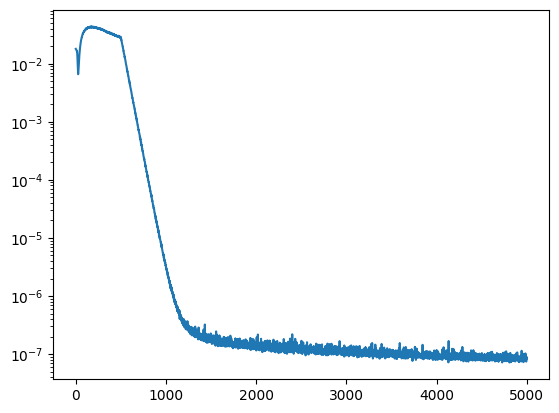

In [50]:
import time

model = model.double()
params = model.params
loss_over_iters = {}
distance_over_iters = {}
bounds = torch.tensor([[-1,1], [-1,1], [-1,1]], dtype=torch.float64)
# Gauss-Newton:
# loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.001, "laplacian": 1.0}
optim = HandNGD(model, lr=1e-2, config=config)
# Adam:
# loss_weights = {"interface": 10.0, "interface_corners": 0.0, "eikonal": 0.4, "laplacian": 1.0}
# optim = torch.optim.Adam(model.parameters(), lr=1e-3)
# eikonal weight has to be small compared to h_laplace, see StabEik

for i in (pbar:=trange(5000)):
    optim.zero_grad()

    ## 1) Interface at boundaries
    loss_interface  = 0.5*model.f(params, pts_boundary).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(model.vf_x(params, pts_eikonal).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    loss_laplacian = 0.5*model.v_f_laplace(params, pts_space).squeeze(1).square().mean()

    if i == 500:
        loss_weights = {"interface": 1.0, "eikonal": 0.0001, "laplacian": 1.0, "curvature": 1.0}
        # loss_weights = {"interface": 1.0, "eikonal": 0.4, "laplacian": 1.0, "curvature": 0.1}
        config["loss_weights"] = loss_weights
        optim.config = config

    grid_find_surface, grid_dist_find_surface, init_grid_resolution = precompute_sample_grid(
                10000, bounds, equidistant=True)

    success, (p_surface, y_sel) = find_boundary_points_numerically_with_binsearch(
        netp=netp, 
        z=torch.zeros([1,0], dtype=torch.float64), ## or correct shape with degenerate shape 
        n_steps=10,
        x_grid=grid_find_surface, 
        x_grid_dist=grid_dist_find_surface, 
        level_set=0.0,
        nf_is_density=True,
        resolution=init_grid_resolution
        )
    if success:
        pts_surface = p_surface.data
        pts_surface = torch.cat((pts_boundary, pts_surface))
        config["pts_surface"] = pts_surface
        optim.config = config
    
    loss_curvature = 0.5*model.v_f_mean_curvature(params, pts_surface).squeeze(1).square().mean()
       
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian + loss_weights["curvature"] * loss_curvature
    # loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["curvature"] * loss_curvature

    loss.backward()
    with torch.no_grad():
        loss_metric = loss_interface + loss_curvature

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"curvature: {loss_curvature.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            f"{len(pts_surface)}"
                            )
        loss_over_iters[i] = loss_metric.item()
        if i > 500:
            distance_over_iters[i], _, _ = compute_distance(model.double(), enneper_level_set)
            # print(distance_over_iters[i])
            # optim.loss = loss_curvature
    optim.step()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

In [51]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface.cpu().detach(), color=0x00ff00, point_size=0.05)

fig.display()

Output()

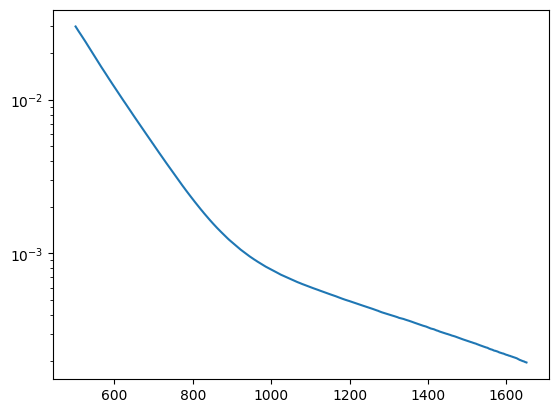

In [36]:
plt.plot(distance_over_iters.keys(), distance_over_iters.values())
plt.semilogy()
plt.show()

### Visualize the result

In [121]:
# def sample_true_surface(n_samples):
#     # Generate radial and angular coordinates
#     r_min, r_max = -1, 1
#     r = torch.linspace(r_min, r_max, n_samples, dtype=torch.float64)
#     phi = torch.linspace(-torch.pi, torch.pi, n_samples, dtype=torch.float64)
    
#     # Create a grid of r and phi
#     r, phi = torch.meshgrid(r, phi, indexing='ij')

#     # Compute the x, y, z coordinates using the parametric equations
#     x, y, z = enneper_surface_polar(r.flatten(), phi.flatten())
#     points_on_surface = torch.vstack([x, y, z]).T

#     return points_on_surface

# def sample_model_surface(implicit_function, n_samples):
#     x = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
#     y = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
#     z = torch.linspace(-1, 1, n_samples, dtype=torch.float64)
    
#     xx, yy, zz = torch.meshgrid(x, y, z, indexing='ij')
#     grid_points = torch.stack([xx.flatten(), yy.flatten(), zz.flatten()], dim=1)
    
#     with torch.no_grad():
#         values = implicit_function(grid_points).squeeze()
#         mask = torch.isclose(values, torch.zeros_like(values), atol=1e-5)  # Adjust tolerance
#         points_on_surface = grid_points[mask]
    
#     return points_on_surface

# def compute_distance(model, true_implicit):    

#     # Sample points on the true implicit surface
#     p_surface_true = sample_true_surface(64)
#     p_surface_model = sample_model_surface(model, 64)

#     # Compute the integral of squared values over both surfaces
#     with torch.no_grad():
#         model_surface_values = model(p_surface_true).squeeze().square()
#         true_surface_values = true_implicit(p_surface_model).squeeze().square()

#     d_model = model_surface_values.mean().sqrt()
#     print(d_model)
#     d_true = true_surface_values.mean().sqrt()
#     print(d_true)

#     # Combine into the distance metric
#     distance = torch.sqrt(d_model**2 + d_true**2).item()

#     return distance, p_surface_true, p_surface_model

# distance, p_surface_true, p_surface_model = compute_distance(model.double(), enneper_level_set)
# print(f"Distance d(f_i, f_j): {distance}")
distance, p_surface_true, p_surface_model = compute_distance(model.double(), enneper_level_set)


In [329]:
p_surface_model.shape

torch.Size([1251, 3])

In [19]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    model.float(), N=128, device=device,
    bbox_min=torch.tensor([-1, -1, -1], dtype=torch.float64),
    bbox_max=torch.tensor([1, 1, 1], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(p_surface_true.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [20]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    enneper_level_set, N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(pts_surface.cpu().detach(), point_size=0.05)
fig.display()

Output()

In [104]:
enneper_level_set(filtered_points).min()

tensor(-12767.0023, device='cuda:0', dtype=torch.float64)

In [99]:
x, y, z = p_surface_model[:, 0], p_surface_model[:, 1], p_surface_model[:, 2]
eps = 1e-2
condition = (torch.abs(z) < eps) & (torch.abs(x - y) < eps)
filtered_points = p_surface_model[condition]

In [105]:
level_set_values = enneper_level_set(filtered_points)

# Find the minimum value
min_value = level_set_values.min()

# Find the indices where the function takes on this minimum value
min_indices = torch.where(level_set_values == min_value)[0]

# Extract the points corresponding to the minimum value
min_points = filtered_points[min_indices]

print("Minimum Value:", min_value.item())
print("Points where the function takes the minimum value:", min_points)

Minimum Value: -12767.00232628519
Points where the function takes the minimum value: tensor([[-6.0176e-01, -5.9374e-01,  2.0383e-04]], device='cuda:0',
       dtype=torch.float64)


In [359]:
test_point = torch.tensor([[-7e-01, -2e-01,  2e-2]])

In [360]:
enneper_level_set(test_point)

tensor([-8.7630e-08], device='cuda:0')

In [361]:
# Generate the mesh using the level set function
verts, faces = get_mesh(
    enneper_level_set, N=128, device=device,
    bbox_min=torch.tensor([-2, -2, -2], dtype=torch.float64),
    bbox_max=torch.tensor([2, 2, 2], dtype=torch.float64),
    chunks=2
)

# Visualization
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig += k3d.points(test_point.cpu().detach(), point_size=0.05)
fig.display()

Output()